# S09 - Обучение НС и оптимизация (PyTorch): Optimizers и Learning Rate

В этом ноутбуке сделаем еще один минимальный эксперимент на нейросети (MLP) и попробуем управлять процессом обучения.

Разбираем:

1) почему **learning rate (LR)** – главный рычаг обучения;  
2) чем отличаются **Adam** и **SGD+momentum** (и почему смена оптимизатора не лечит плохой LR);  
3) что такое **weight decay** и как он помогает как простая регуляризация.

## 0. План

К концу ноутбука надо уметь:

- обучить MLP в PyTorch (train/eval цикл, валидация);
- по графикам train/val loss понять, что происходит:
  - LR слишком большой – значит нестабильность/расходимость;
  - LR слишком маленький – по сути ползёт;
  - LR нормальный – стабильная сходимость;
- сравнить Adam vs SGD+momentum на **одинаковой** задаче;
- аккуратно собрать результаты в простую таблицу.

Договорённость: **не делаем сложные пайплайны**. Это простоый учебный эксперимент: несколько прогонов, графики, вывод.

## 1. Импорты и общие настройки

Ниже – как всегда минимальные библиотеки:

- `torch` – основной фреймворк;
- `matplotlib` – графики (без seaborn);
- `pandas` – удобная таблица результатов.

Датасет: по умолчанию хотим `KMNIST` из `torchvision`.  
Но чтобы ноутбук был **устойчивым** в разных средах, сделан fallback: если `torchvision` недоступен, используем `sklearn.datasets.load_digits` (тоже 10 классов, но маленький и быстрый).

In [1]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Данные: загрузка, train/val/test, DataLoader

Сейчас нам важны:

- быстрое обучение (чтобы успеть сравнить несколько прогонов);
- классификация (чтобы видеть и loss, и accuracy);
- воспроизводимое разбиение на train/val/test.

Параметры ниже можно менять, но для демонстрации обычно достаточно режима `FAST_MODE=True`, чтобы всё быстро выполнялось даже на CPU.

In [2]:
from torch.utils.data import DataLoader, TensorDataset, random_split

@dataclass
class DataConfig:
    dataset_name: str = "KMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.15
    num_workers: int = 0
    fast_mode: bool = True
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

def _try_load_torchvision_dataset(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms

    name = cfg.dataset_name.upper().strip()

    if name in {"KMNIST", "EMNIST"}:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    if name == "KMNIST":
        train_ds = datasets.KMNIST(root=cfg.data_dir, train=True, download=True, transform=transform)
        test_ds  = datasets.KMNIST(root=cfg.data_dir, train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 10, "torchvision.KMNIST (28x28, 10 классов)"

    if name == "EMNIST":
        train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
        test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"

    if name == "CIFAR10":
        transform_cifar = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
        ])
        train_ds = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=transform_cifar)
        test_ds  = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=transform_cifar)
        return train_ds, test_ds, 32 * 32 * 3, 10, "torchvision.CIFAR10 (32x32x3, 10 классов)"

    raise ValueError(f"Unknown torchvision dataset_name={cfg.dataset_name!r}")

def _load_digits_fallback(cfg: DataConfig):
    """Запасной вариант без torchvision: sklearn.datasets.load_digits."""
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split

    digits = load_digits()
    X = digits.data.astype(np.float32)     # (n, 64)
    y = digits.target.astype(np.int64)     # (n,)

    # Нормируем в [0, 1]
    X = X / (X.max() + 1e-8)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
    return train_ds, test_ds, X.shape[1], int(y.max() + 1), "sklearn.load_digits (8x8 => 64 признака, 10 классов) [fallback]"

def load_data(cfg: DataConfig):
    try:
        train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset(cfg)
    except Exception as e:
        print("torchvision недоступен или датасет не загрузился. Используем fallback digits. Причина:", repr(e))
        cfg.dataset_name = "DIGITS_FALLBACK"
        train_ds, test_ds, input_dim, num_classes, info = _load_digits_fallback(cfg)

    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds
        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)

100%|██████████| 562M/562M [00:03<00:00, 144MB/s] 


Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47


### Быстрый sanity-check: один батч

Проверим, что формы тензоров корректны.

In [3]:
def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x

print("x_flat:", x_flat.shape)

x: <class 'torch.Tensor'> torch.Size([128, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([128]) torch.int64
x_flat: torch.Size([128, 784])


## 3. Модель: простой MLP

Сегодня мы точно **не соревнуемся архитектурами**.  
Сегодняшняя цель – научиться управлять обучением: LR, оптимизаторы, weight decay.

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 256, hidden2: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(model)
print("Trainable params:", count_params(model))

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable params: 239919


## 4. Цикл обучения: train/eval и история

Делаем минимум: train на train и оценка на val с `model.eval()` и `torch.no_grad()`.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=6, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

    return history


def plot_history(hist, title=""):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

## 5. Базовый прогон (контрольная точка)

Прежде чем делать плохие LR, убедимся, что всё обучается на нормальном LR.

Для Adam типичный старт: `lr=1e-3`.

Epoch 01/6 | train loss 2.4979, acc 0.345 | val loss 1.6180, acc 0.559 | 3.3s
Epoch 02/6 | train loss 1.4624, acc 0.584 | val loss 1.3363, acc 0.621 | 3.6s
Epoch 03/6 | train loss 1.2255, acc 0.644 | val loss 1.1753, acc 0.653 | 2.8s
Epoch 04/6 | train loss 1.0924, acc 0.675 | val loss 1.1093, acc 0.666 | 2.7s
Epoch 05/6 | train loss 0.9804, acc 0.702 | val loss 1.0158, acc 0.695 | 2.8s
Epoch 06/6 | train loss 0.8690, acc 0.739 | val loss 0.9398, acc 0.727 | 3.5s


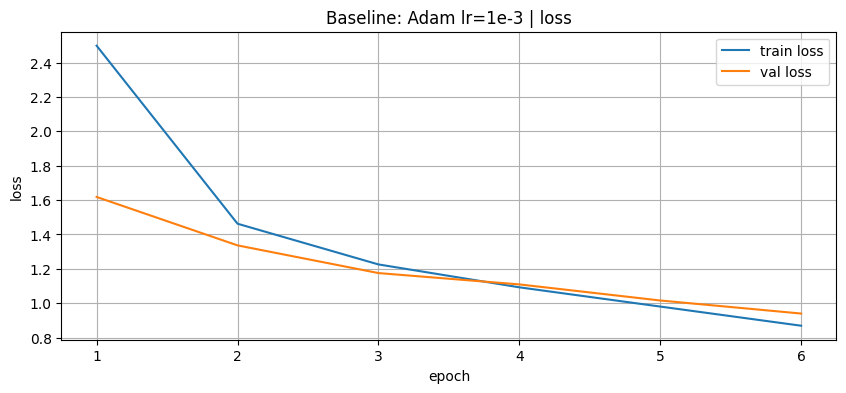

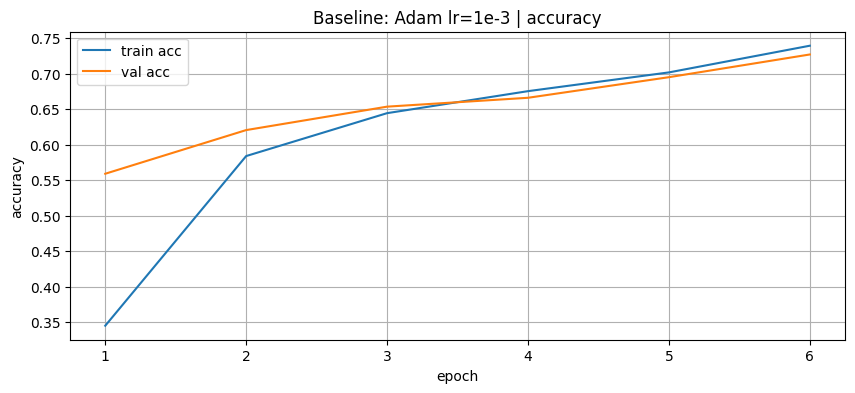

In [6]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def make_model():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

baseline_model = make_model()
baseline_opt = make_optimizer(baseline_model, kind="adam", lr=1e-3, weight_decay=0.0)

baseline_hist = fit(baseline_model, train_loader, val_loader, baseline_opt, criterion, epochs=EPOCHS)
plot_history(baseline_hist, title="Baseline: Adam lr=1e-3")

## 6. Эксперимент 1: LR sweep (Adam)

Сделаем 3 запуска с Adam, меняя **только LR**.

- LR_high: слишком большой – скачки/расходимость/NaN
- LR_ok: нормальный
- LR_low: слишком маленький – ползёт


Experiment LR_high: Adam lr=0.1
Epoch 01/6 | train loss 17.8257, acc 0.021 | val loss 3.8628, acc 0.017 | 2.8s
Epoch 02/6 | train loss 3.9239, acc 0.021 | val loss 3.8672, acc 0.019 | 2.7s
Epoch 03/6 | train loss 3.8622, acc 0.021 | val loss 3.8600, acc 0.019 | 2.8s
Epoch 04/6 | train loss 3.8625, acc 0.021 | val loss 3.8634, acc 0.023 | 3.1s
Epoch 05/6 | train loss 3.8627, acc 0.020 | val loss 3.8678, acc 0.020 | 3.0s
Epoch 06/6 | train loss 3.8630, acc 0.022 | val loss 3.8659, acc 0.016 | 2.7s


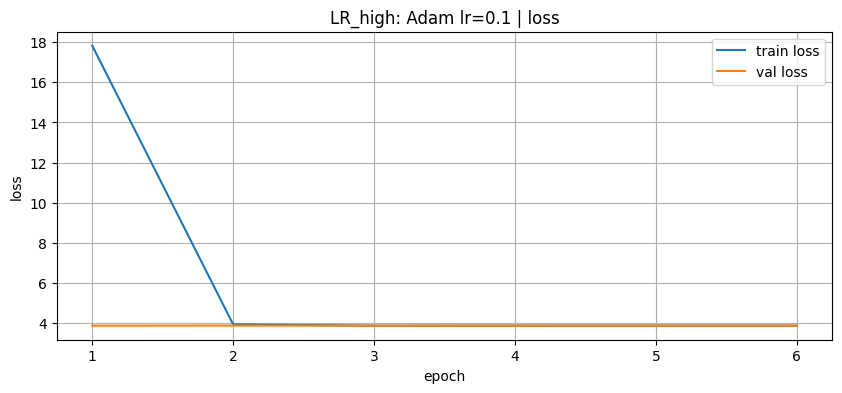

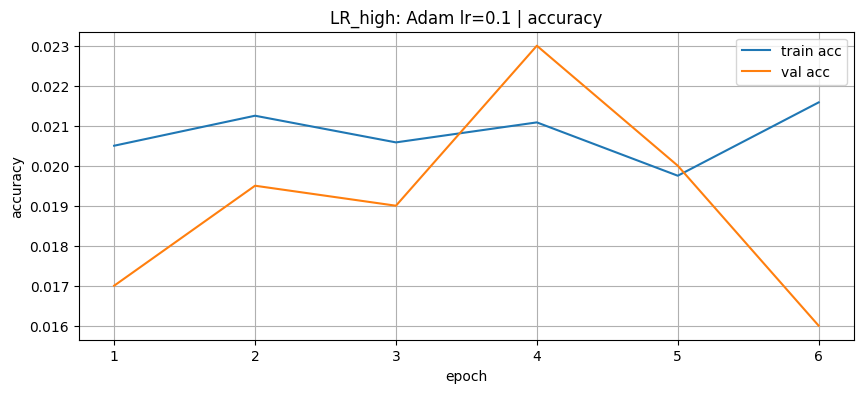


Experiment LR_ok: Adam lr=0.001
Epoch 01/6 | train loss 2.4236, acc 0.363 | val loss 1.5921, acc 0.552 | 2.8s
Epoch 02/6 | train loss 1.4534, acc 0.582 | val loss 1.3402, acc 0.613 | 3.1s
Epoch 03/6 | train loss 1.2367, acc 0.638 | val loss 1.1999, acc 0.660 | 3.4s
Epoch 04/6 | train loss 1.1154, acc 0.671 | val loss 1.1025, acc 0.675 | 2.7s
Epoch 05/6 | train loss 0.9871, acc 0.705 | val loss 1.0513, acc 0.691 | 2.8s
Epoch 06/6 | train loss 0.9043, acc 0.730 | val loss 0.9526, acc 0.722 | 2.8s


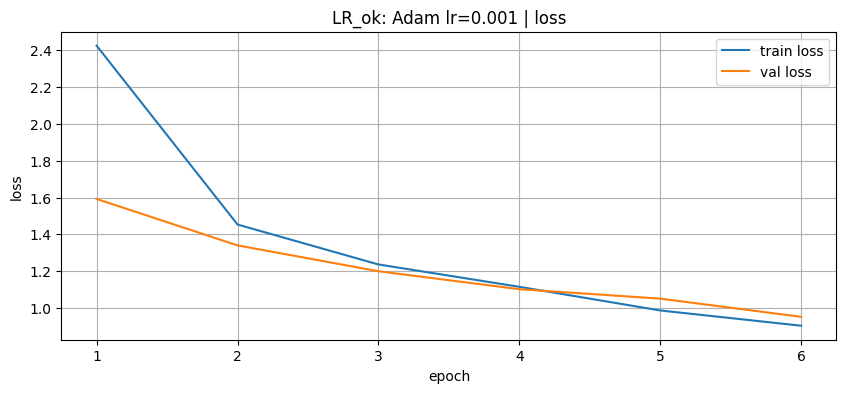

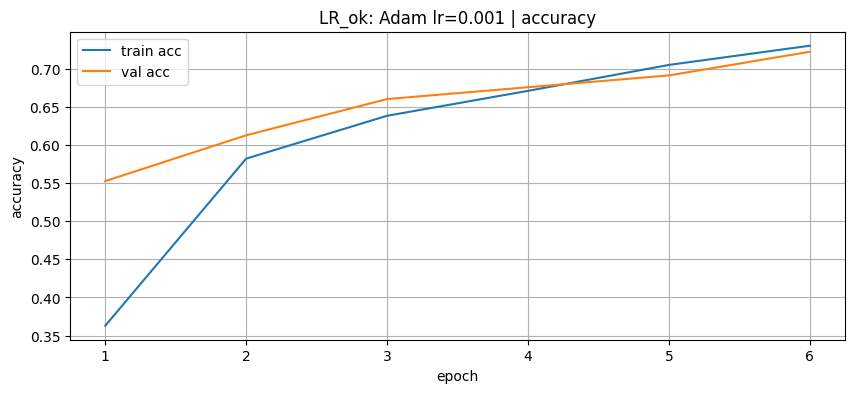


Experiment LR_low: Adam lr=1e-05
Epoch 01/6 | train loss 3.8429, acc 0.022 | val loss 3.8286, acc 0.035 | 3.4s
Epoch 02/6 | train loss 3.8133, acc 0.051 | val loss 3.7979, acc 0.057 | 2.7s
Epoch 03/6 | train loss 3.7775, acc 0.070 | val loss 3.7583, acc 0.075 | 2.7s
Epoch 04/6 | train loss 3.7330, acc 0.090 | val loss 3.7115, acc 0.100 | 2.7s
Epoch 05/6 | train loss 3.6804, acc 0.120 | val loss 3.6564, acc 0.132 | 3.5s
Epoch 06/6 | train loss 3.6208, acc 0.159 | val loss 3.5950, acc 0.165 | 2.7s


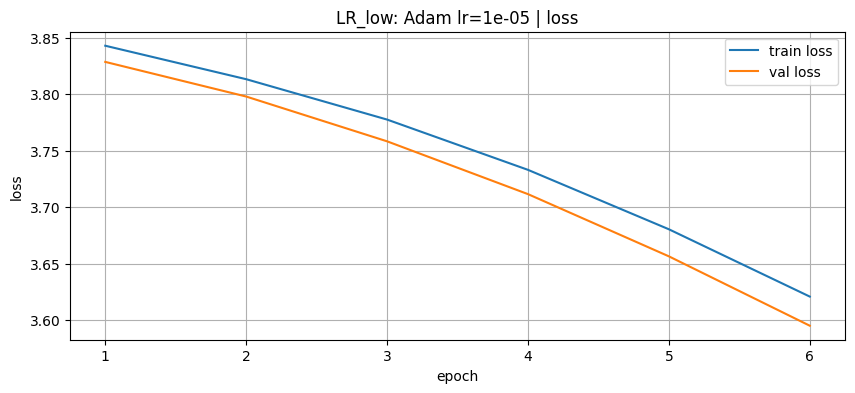

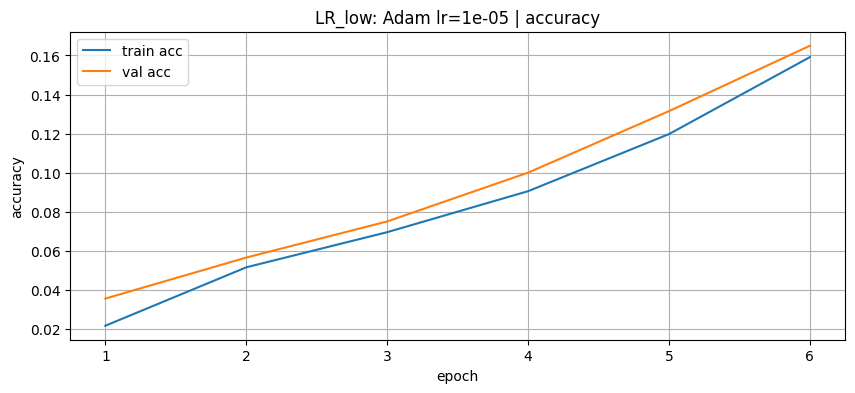

In [7]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("LR_high", 1e-1),
    ("LR_ok",   1e-3),
    ("LR_low",  1e-5),
]

results_lr = []
for name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr)
    results_lr.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")

### Сводка по LR sweep

In [8]:
rows = []
for r in results_lr:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_lr)

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
1,LR_ok,adam,0.00100,0.0,6,0.722,0.952606
2,LR_low,adam,0.00001,0.0,6,0.165,3.594974
0,LR_high,adam,0.10000,0.0,6,0.023,3.859997


## 7. Эксперимент 2: Adam vs SGD+momentum

Теперь сравним оптимизаторы на одинаковой задаче.

Важно: для SGD нужен LR **другого масштаба**.


Experiment OPT_Adam: Adam lr=1e-3
Epoch 01/6 | train loss 2.5250, acc 0.332 | val loss 1.6380, acc 0.538 | 2.7s
Epoch 02/6 | train loss 1.4580, acc 0.586 | val loss 1.3558, acc 0.610 | 2.7s
Epoch 03/6 | train loss 1.2459, acc 0.633 | val loss 1.2044, acc 0.650 | 3.5s
Epoch 04/6 | train loss 1.0965, acc 0.678 | val loss 1.1052, acc 0.671 | 2.8s
Epoch 05/6 | train loss 0.9807, acc 0.710 | val loss 1.0380, acc 0.694 | 2.8s
Epoch 06/6 | train loss 0.9008, acc 0.725 | val loss 0.9602, acc 0.713 | 2.7s


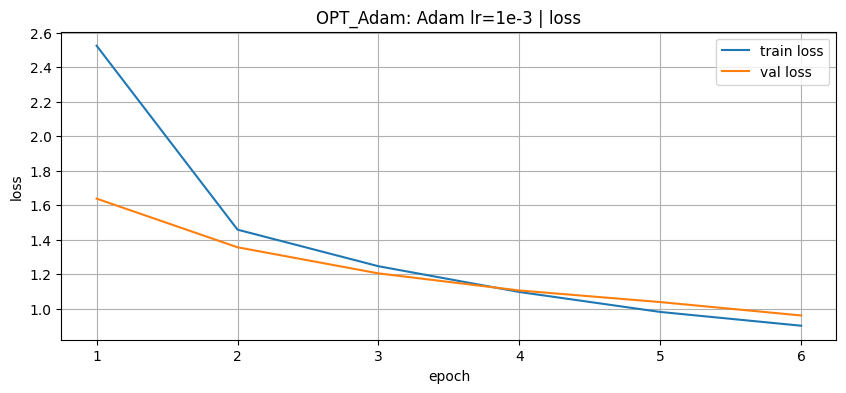

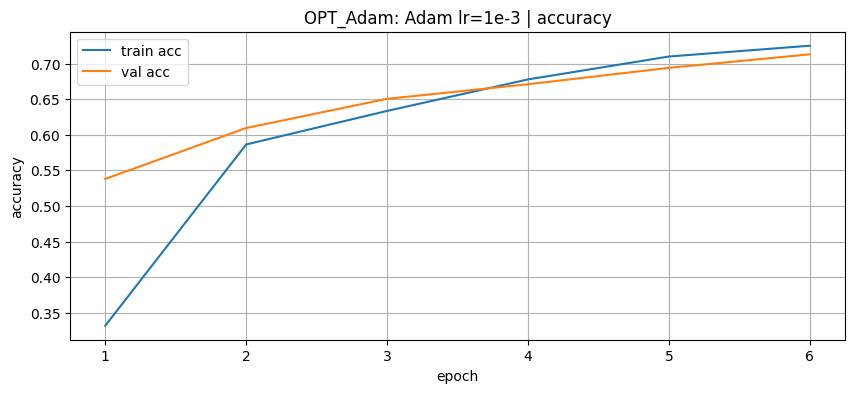


Experiment OPT_SGD: SGD lr=0.1 momentum=0.9
Epoch 01/6 | train loss 2.3274, acc 0.357 | val loss 1.7090, acc 0.489 | 3.4s
Epoch 02/6 | train loss 1.4296, acc 0.569 | val loss 1.2828, acc 0.618 | 2.8s
Epoch 03/6 | train loss 1.2052, acc 0.628 | val loss 1.2086, acc 0.627 | 2.8s
Epoch 04/6 | train loss 1.1510, acc 0.643 | val loss 1.2077, acc 0.640 | 2.8s
Epoch 05/6 | train loss 1.0810, acc 0.661 | val loss 1.1856, acc 0.663 | 3.1s
Epoch 06/6 | train loss 0.9906, acc 0.687 | val loss 1.2714, acc 0.644 | 3.1s


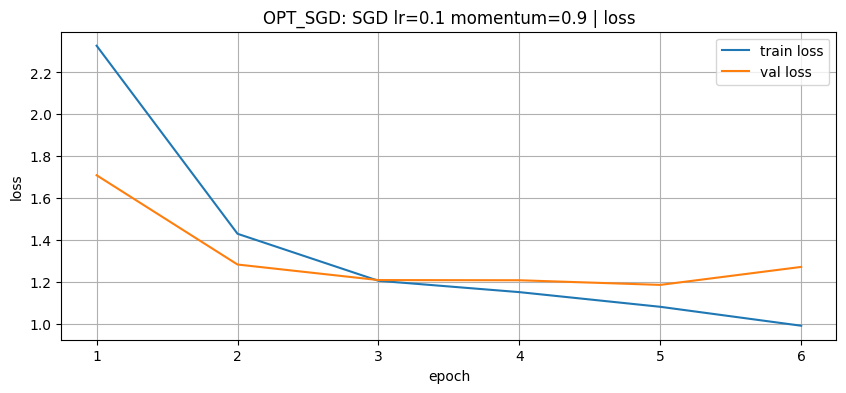

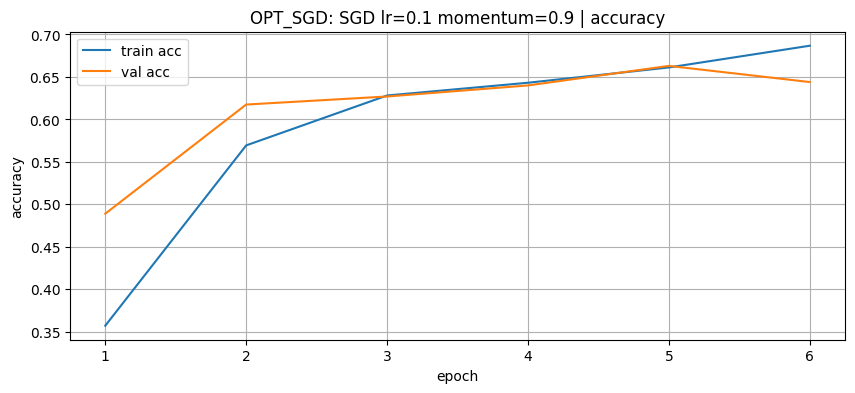

,exp_id,optimizer,lr,momentum,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,OPT_Adam,adam,0.001,NaN,0.0,6,0.713,0.960237
1,OPT_SGD,sgd,0.100,0.9,0.0,6,0.663,1.185564


In [9]:
results_opt = []

print("\n" + "="*80)
print("Experiment OPT_Adam: Adam lr=1e-3")
res_adam = run_experiment(exp_id="OPT_Adam", optimizer_kind="adam", lr=1e-3)
results_opt.append(res_adam)
plot_history(res_adam["history"], title="OPT_Adam: Adam lr=1e-3")

print("\n" + "="*80)
print("Experiment OPT_SGD: SGD lr=0.1 momentum=0.9")
res_sgd = run_experiment(exp_id="OPT_SGD", optimizer_kind="sgd", lr=0.1, momentum=0.9)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="OPT_SGD: SGD lr=0.1 momentum=0.9")

rows = []
for r in results_opt:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_opt = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_opt)

## 8. Эксперимент 3: weight decay (Adam)

`weight_decay` = L2-регуляризация на уровне оптимизатора.

Сравним несколько значений на Adam с фиксированным LR.


Experiment WD_0: Adam lr=1e-3 weight_decay=0.0
Epoch 01/6 | train loss 2.4625, acc 0.356 | val loss 1.5876, acc 0.542 | 2.8s
Epoch 02/6 | train loss 1.4446, acc 0.582 | val loss 1.3810, acc 0.610 | 2.8s
Epoch 03/6 | train loss 1.2304, acc 0.638 | val loss 1.2239, acc 0.650 | 3.0s
Epoch 04/6 | train loss 1.0816, acc 0.677 | val loss 1.1253, acc 0.670 | 3.2s
Epoch 05/6 | train loss 0.9729, acc 0.711 | val loss 1.0176, acc 0.704 | 2.7s
Epoch 06/6 | train loss 0.8882, acc 0.727 | val loss 0.9826, acc 0.706 | 2.7s


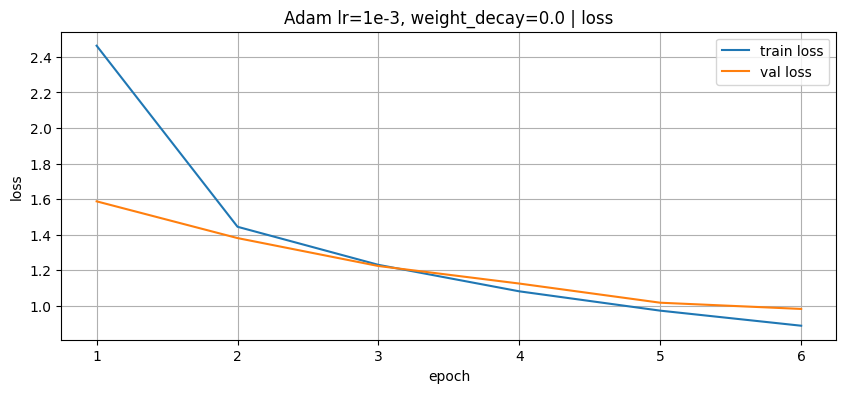

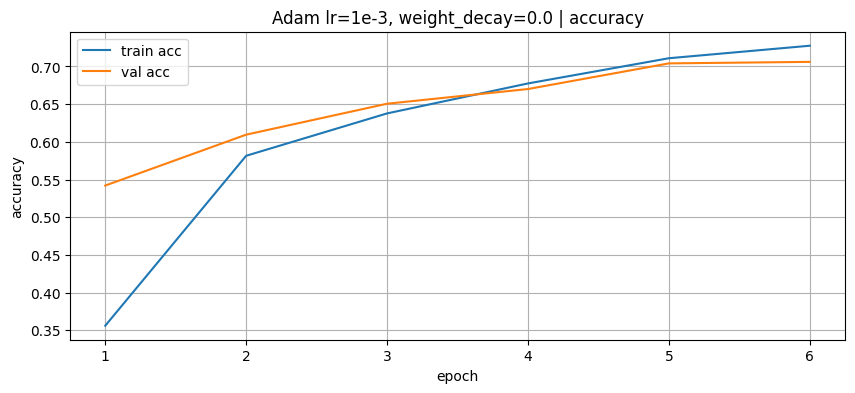


Experiment WD_0.0001: Adam lr=1e-3 weight_decay=0.0001
Epoch 01/6 | train loss 2.4384, acc 0.366 | val loss 1.6115, acc 0.543 | 2.7s
Epoch 02/6 | train loss 1.4441, acc 0.587 | val loss 1.3697, acc 0.607 | 3.5s
Epoch 03/6 | train loss 1.2234, acc 0.644 | val loss 1.2008, acc 0.655 | 2.7s
Epoch 04/6 | train loss 1.0903, acc 0.676 | val loss 1.0917, acc 0.677 | 2.7s
Epoch 05/6 | train loss 0.9674, acc 0.713 | val loss 1.0143, acc 0.699 | 2.7s
Epoch 06/6 | train loss 0.8864, acc 0.731 | val loss 0.9507, acc 0.720 | 3.4s


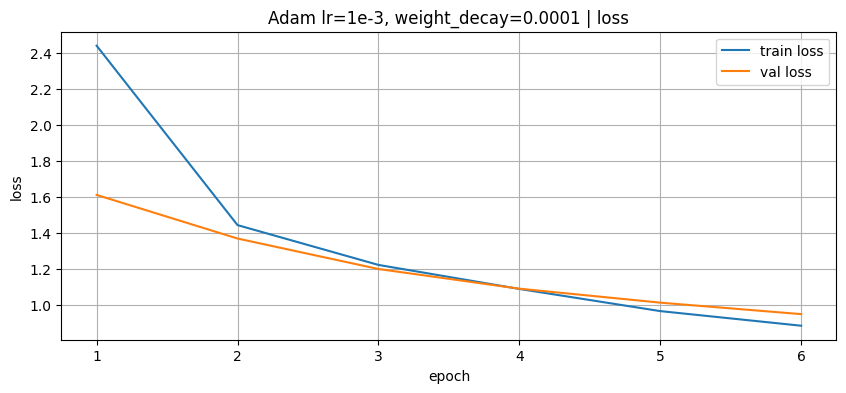

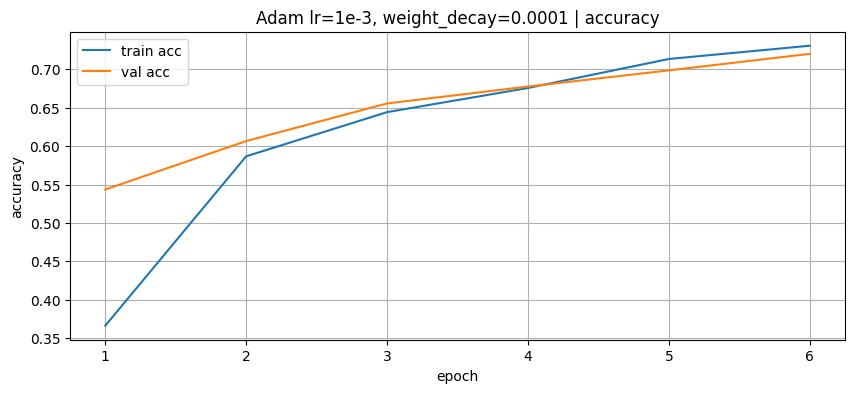


Experiment WD_0.001: Adam lr=1e-3 weight_decay=0.001
Epoch 01/6 | train loss 2.4811, acc 0.350 | val loss 1.7142, acc 0.503 | 2.7s
Epoch 02/6 | train loss 1.4702, acc 0.576 | val loss 1.3620, acc 0.607 | 2.7s
Epoch 03/6 | train loss 1.2433, acc 0.637 | val loss 1.2114, acc 0.653 | 2.7s
Epoch 04/6 | train loss 1.1043, acc 0.672 | val loss 1.1006, acc 0.678 | 3.4s
Epoch 05/6 | train loss 0.9978, acc 0.700 | val loss 1.0181, acc 0.695 | 2.7s
Epoch 06/6 | train loss 0.9061, acc 0.723 | val loss 0.9648, acc 0.722 | 2.7s


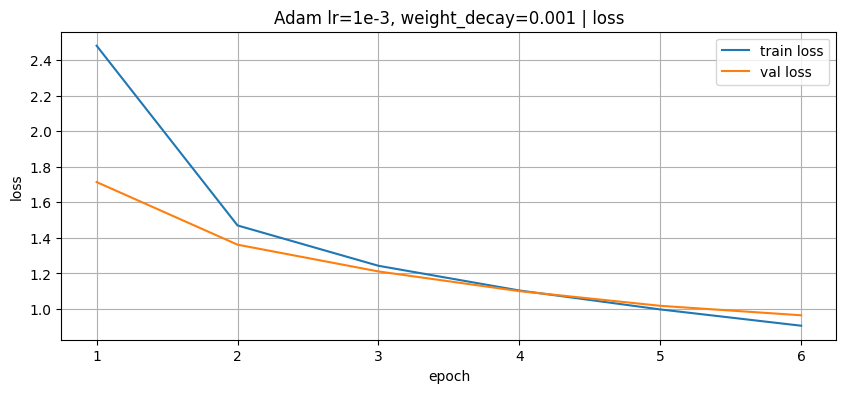

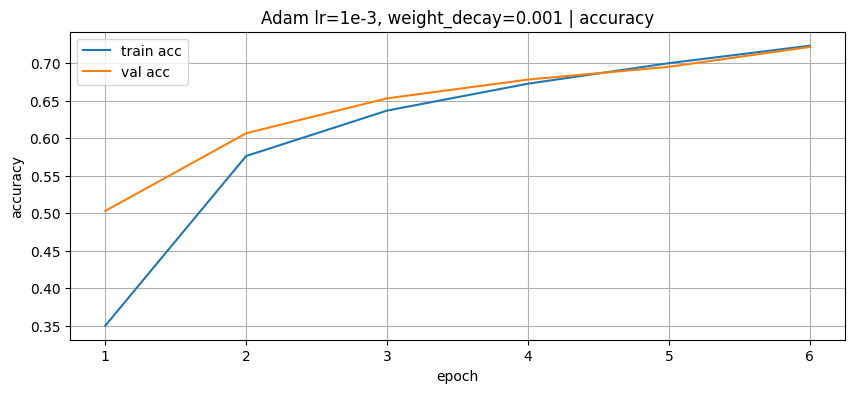

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
2,WD_0.001,adam,0.001,0.0010,6,0.7215,0.964805
1,WD_0.0001,adam,0.001,0.0001,6,0.7200,0.950661
0,WD_0,adam,0.001,0.0000,6,0.7060,0.982629


In [10]:
wd_values = [0.0, 1e-4, 1e-3]

results_wd = []
for wd in wd_values:
    print("\n" + "="*80)
    print(f"Experiment WD_{wd:g}: Adam lr=1e-3 weight_decay={wd}")
    res = run_experiment(exp_id=f"WD_{wd:g}", optimizer_kind="adam", lr=1e-3, weight_decay=wd)
    results_wd.append(res)
    plot_history(res["history"], title=f"Adam lr=1e-3, weight_decay={wd}")

rows = []
for r in results_wd:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_wd = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_wd)

## 9. Итог: что запомнить

1) **Learning rate** – главный рычаг. Плохой LR не лечится сменой оптимизатора.
2) **Adam** часто стартует нормально из коробки, но это адаптивный шаг.
3) **SGD+momentum** может быть отличным, но требует аккуратного LR и часто расписаний LR.
4) **Weight decay** – простой способ ограничить сложность модели и иногда улучшить val-качество.

### Контрольные вопросы

- Как по графикам понять, что LR слишком большой?
- Почему у SGD и Adam разные "типичные" масштабы LR?
- Чем weight decay отличается от Dropout?